In [1]:
# ===== 1. Import libraries =====
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Use GPU in Google Colab if available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


## 2. Data Preprocessing

Dataset used: **MNIST**.  
The images are loaded, normalized, and split into training, validation, and testing sets. Data augmentation is added for the training set as an optional bonus.

In [2]:
# ===== 2. Data preprocessing =====
# Training transform: augmentation + conversion to tensor + normalization
train_transform = transforms.Compose([
    transforms.RandomRotation(10),          # optional data augmentation
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Test/validation transform: no augmentation, only tensor + normalization
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download MNIST training and testing datasets
full_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=val_test_transform
)

# Split original training set into train and validation sets
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# IMPORTANT: validation dataset should not use random augmentation
val_dataset.dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=False,
    transform=val_test_transform
)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))
print("Classes:", test_dataset.classes)

100%|██████████| 9.91M/9.91M [00:00<00:00, 24.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 617kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.83MB/s]


Training samples: 54000
Validation samples: 6000
Testing samples: 10000
Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


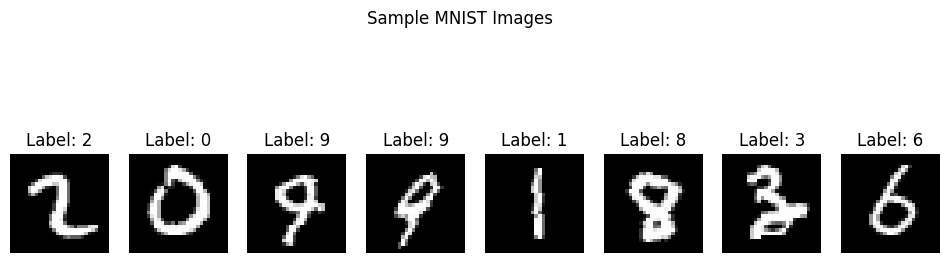

In [3]:
# ===== Display sample images =====
examples = iter(train_loader)
images, labels = next(examples)

plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    img = images[i].squeeze().numpy()
    plt.imshow(img, cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")
plt.suptitle("Sample MNIST Images")
plt.show()

## 3. CNN Model Implementation

The model includes:
- At least 2 convolutional layers
- ReLU activation
- Pooling layer
- Flatten operation
- Fully connected dense layer
- Output layer for 10 MNIST classes
- Bonus: Batch Normalization and Dropout

In [4]:
# ===== 3. CNN model from scratch using PyTorch =====
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # Input shape: 1 x 28 x 28
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.30)

        # After two pooling layers: 28x28 -> 14x14 -> 7x7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # CrossEntropyLoss applies Softmax internally
        return x

model = CNNModel().to(DEVICE)
print(model)

CNNModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4. Compile / Configure the Model

For PyTorch, compiling means defining the loss function and optimizer.

In [5]:
# ===== 4. Loss function and optimizer =====
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 5. Model Training

The model is trained for **10 epochs**, and training/validation accuracy and loss are stored for visualization.

In [6]:
# ===== Helper functions for training and validation =====
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

In [7]:
# ===== 5. Train model for minimum 10 epochs =====
EPOCHS = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
    )

Epoch [1/10] Train Loss: 0.1935 | Train Acc: 93.97% | Val Loss: 0.0599 | Val Acc: 98.10%
Epoch [2/10] Train Loss: 0.0836 | Train Acc: 97.46% | Val Loss: 0.0557 | Val Acc: 98.40%
Epoch [3/10] Train Loss: 0.0681 | Train Acc: 97.89% | Val Loss: 0.0412 | Val Acc: 98.78%
Epoch [4/10] Train Loss: 0.0595 | Train Acc: 98.17% | Val Loss: 0.0403 | Val Acc: 98.88%
Epoch [5/10] Train Loss: 0.0527 | Train Acc: 98.36% | Val Loss: 0.0352 | Val Acc: 98.90%
Epoch [6/10] Train Loss: 0.0457 | Train Acc: 98.56% | Val Loss: 0.0298 | Val Acc: 99.20%
Epoch [7/10] Train Loss: 0.0421 | Train Acc: 98.71% | Val Loss: 0.0434 | Val Acc: 98.90%
Epoch [8/10] Train Loss: 0.0391 | Train Acc: 98.79% | Val Loss: 0.0395 | Val Acc: 99.00%
Epoch [9/10] Train Loss: 0.0360 | Train Acc: 98.87% | Val Loss: 0.0335 | Val Acc: 99.10%
Epoch [10/10] Train Loss: 0.0343 | Train Acc: 98.92% | Val Loss: 0.0325 | Val Acc: 99.17%


## 6. Evaluation

The trained CNN is evaluated on the separate test dataset. Accuracy, classification report, and confusion matrix are shown.

In [12]:
# ===== 6. Evaluate on test data =====
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, DEVICE)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print("\nClassification Report:\n")
print(classification_report(test_labels, test_preds, target_names=test_dataset.classes))


Test Loss: 0.0208
Test Accuracy: 99.43%

Classification Report:

              precision    recall  f1-score   support

    0 - zero       0.99      1.00      1.00       980
     1 - one       1.00      1.00      1.00      1135
     2 - two       0.99      1.00      0.99      1032
   3 - three       0.99      0.99      0.99      1010
    4 - four       1.00      0.99      1.00       982
    5 - five       0.99      0.99      0.99       892
     6 - six       1.00      0.99      0.99       958
   7 - seven       0.99      0.99      0.99      1028
   8 - eight       0.99      0.99      0.99       974
    9 - nine       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



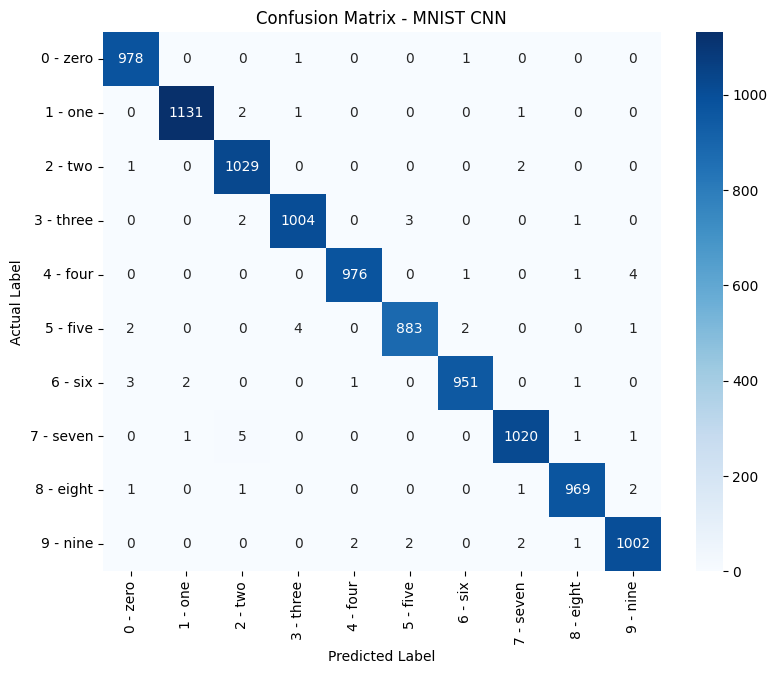

In [19]:
# ===== Confusion matrix =====
# Ensure test_labels and test_preds are defined before creating the confusion matrix.
# This handles cases where the cell might be run out of order or after a kernel restart.
if 'test_labels' not in globals() or 'test_preds' not in globals():
    print("Warning: 'test_labels' or 'test_preds' not found. Re-running evaluation to define them.")
    test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, DEVICE)

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - MNIST CNN")
plt.show()


## 7. Visualization

Training and validation accuracy/loss curves are plotted below.

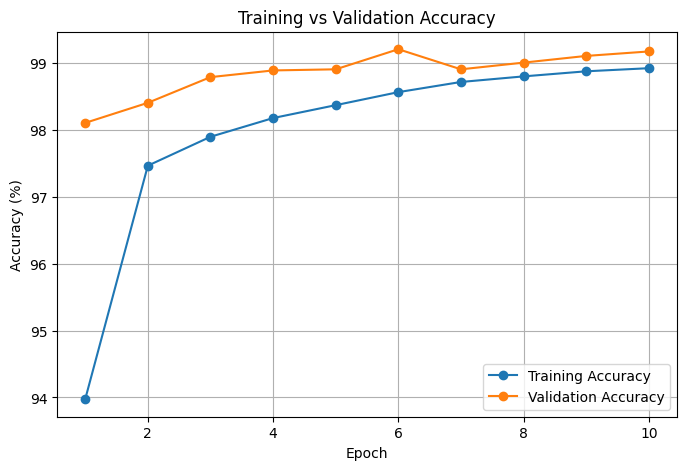

In [14]:
# ===== Plot training vs validation accuracy =====
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_accuracies, marker="o", label="Training Accuracy")
plt.plot(range(1, EPOCHS + 1), val_accuracies, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

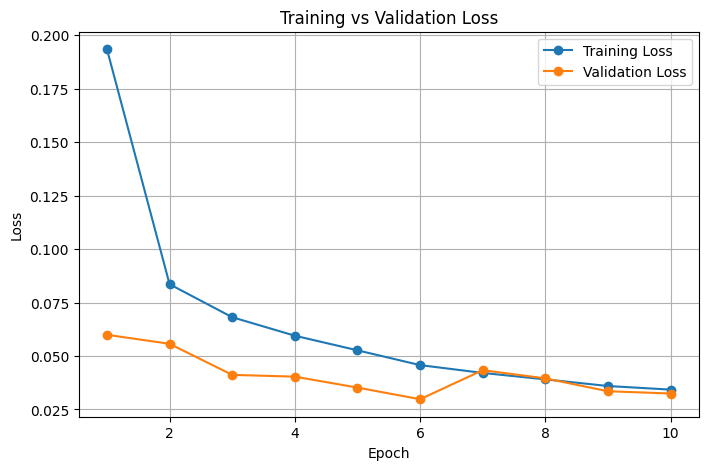

In [15]:
# ===== Plot training vs validation loss =====
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o", label="Training Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

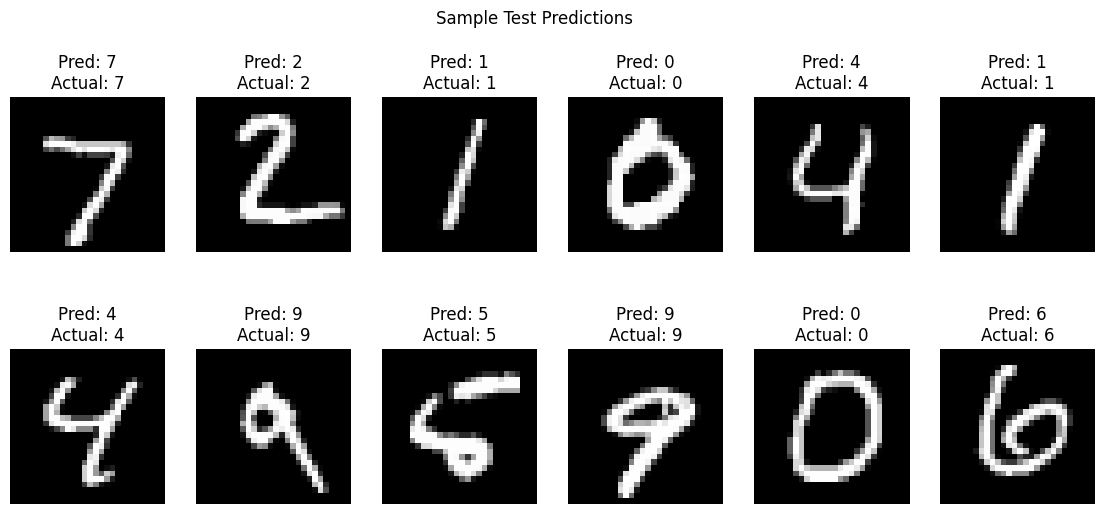

In [24]:
# ===== Show a few predictions =====
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(DEVICE), labels.to(DEVICE)

with torch.no_grad():
    outputs = model(images)
    _, predictions = torch.max(outputs, 1)

plt.figure(figsize=(14, 6))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(images[i].cpu().squeeze(), cmap="gray")
    plt.title(f"Pred: {predictions[i].item()}\nActual: {labels[i].item()}")
    plt.axis("off")
plt.suptitle("Sample Test Predictions")
plt.show()


## 8. Required Analysis Questions

**1. What is the role of convolution layers?**  
Convolution layers automatically extract important visual features from images, such as edges, curves, textures, and shapes. In this MNIST model, the first convolution layer can learn simple features such as stroke edges, while deeper convolution layers can learn more meaningful digit patterns.

**2. Why is pooling used?**  
Pooling reduces the spatial size of feature maps. This lowers computational cost, reduces the number of parameters, and helps the model focus on the most important features. Max pooling also makes the model slightly more robust to small shifts in the image.

**3. What happens if we increase the number of filters?**  
Increasing the number of filters allows the CNN to learn more feature patterns. This can improve accuracy because the model becomes more powerful. However, it also increases training time, memory use, and the risk of overfitting if the dataset is small or the model becomes too complex.

**4. What is overfitting in CNN? Did it occur in your model?**  
Overfitting happens when a CNN performs very well on training data but poorly on validation or test data. It means the model memorized the training examples instead of learning general patterns. In this model, overfitting can be checked by comparing training and validation curves. If training accuracy is much higher than validation accuracy, or validation loss increases while training loss decreases, overfitting is occurring. Dropout, Batch Normalization, data augmentation, and validation monitoring were used to reduce overfitting. After running the notebook, if the training and validation accuracy curves remain close, then major overfitting did not occur.

## 9. Bonus: Simple Upload Image Prediction in Colab

Run this section only in Google Colab. Upload a digit image, and the trained model will predict the class.

Saving 2-digit-number-two.jpg to 2-digit-number-two.jpg


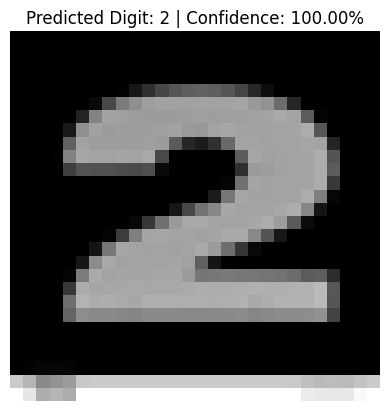

In [22]:
# ===== Bonus: upload an image and predict digit class in Google Colab =====
# Run this cell only in Google Colab after training the model.

try:
    from google.colab import files
    from PIL import Image, ImageOps
    import io

    uploaded = files.upload()

    for filename in uploaded.keys():
        image = Image.open(io.BytesIO(uploaded[filename])).convert("L")
        image = ImageOps.invert(image)  # useful if digit is dark on light background
        image = image.resize((28, 28))

        transform_for_prediction = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])

        input_tensor = transform_for_prediction(image).unsqueeze(0).to(DEVICE)

        model.eval()
        with torch.no_grad():
            output = model(input_tensor)
            probabilities = F.softmax(output, dim=1)
            confidence, predicted_class = torch.max(probabilities, 1)

        plt.imshow(image, cmap="gray")
        plt.axis("off")
        plt.title(f"Predicted Digit: {predicted_class.item()} | Confidence: {confidence.item()*100:.2f}%")
        plt.show()

except ModuleNotFoundError:
    print("This upload cell works only in Google Colab.")